# Toy tasks demo

Demonstrates the three timeseries-of-vectors tasks in `toy_v0/tasks`:

1. **Binary noise** -- i.i.d. Bernoulli noise per timestep (with optional partial resampling)
2. **Drift** -- a Bernoulli vector that shifts to the right each timestep
3. **Gaussian process** -- an analog vector in [0, 1] correlated over space and time

In [15]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from tasks import BinaryNoiseTask, DriftTask, GaussianProcessTask, BifurcateTask

def plot_timeseries(data, title, vmin=0, vmax=1):
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(data.T, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_xlabel('timestep')
    ax.set_ylabel('vector element')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.show()

## 1. Binary noise

With the default `resample_prob=1`, every element is redrawn every timestep (fully independent noise).

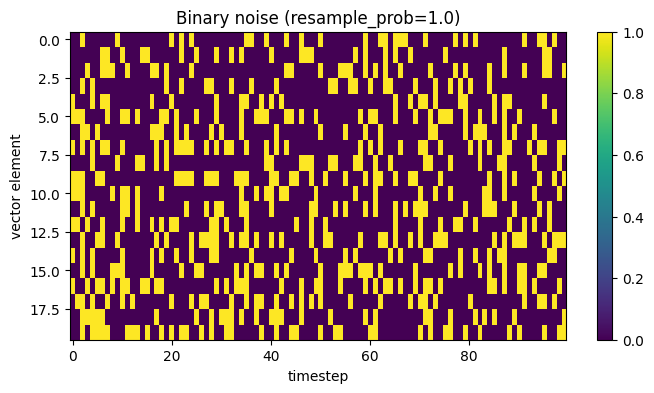

In [16]:
task = BinaryNoiseTask(vector_length=20, prob=0.3, resample_prob=1.0)
data = task.generate(num_steps=100, seed=0)
plot_timeseries(data, 'Binary noise (resample_prob=1.0)')

With a lower `resample_prob`, elements only occasionally resample and otherwise hold their value, giving "stickier" noise.

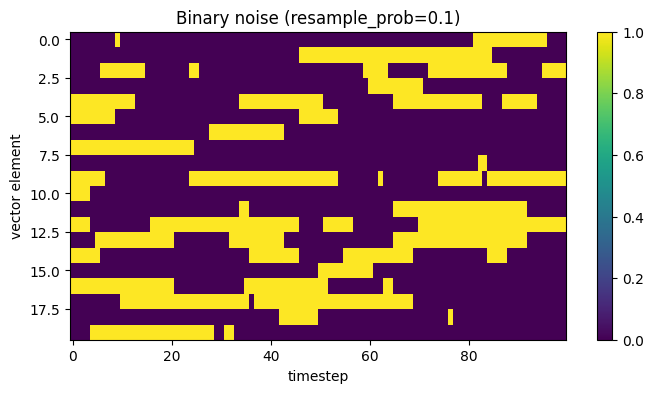

In [17]:
task = BinaryNoiseTask(vector_length=20, prob=0.3, resample_prob=0.1)
data = task.generate(num_steps=100, seed=0)
plot_timeseries(data, 'Binary noise (resample_prob=0.1)')

## 2. Drift

A fresh Bernoulli sample enters on the left each timestep and the vector shifts right, so each element's history traces a diagonal band.

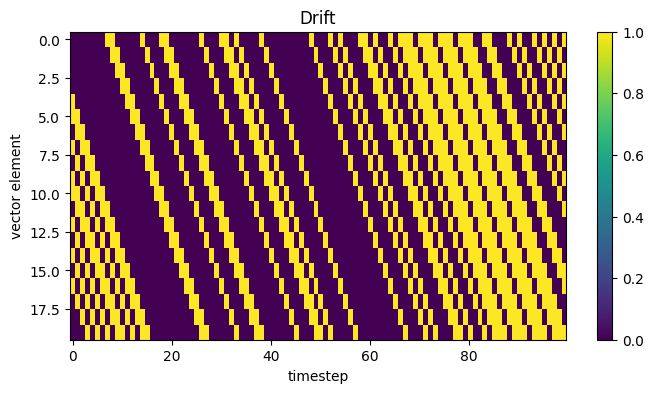

In [18]:
task = DriftTask(vector_length=20, prob=0.3)
data = task.generate(num_steps=100, seed=0)
plot_timeseries(data, 'Drift')

## 3. Gaussian process over space and time

`spatial_temperature` controls the correlation lengthscale across vector elements; `temporal_temperature` controls the correlation lengthscale across timesteps. Larger values give smoother (more correlated) fields.

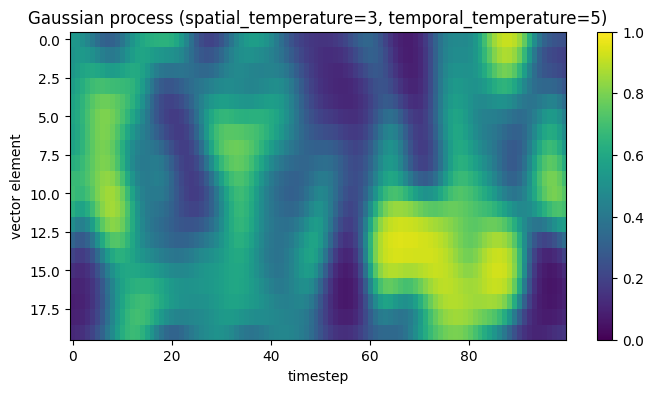

In [19]:
task = GaussianProcessTask(vector_length=20, spatial_temperature=3.0, temporal_temperature=5.0)
data = task.generate(num_steps=100, seed=0)
plot_timeseries(data, 'Gaussian process (spatial_temperature=3, temporal_temperature=5)')

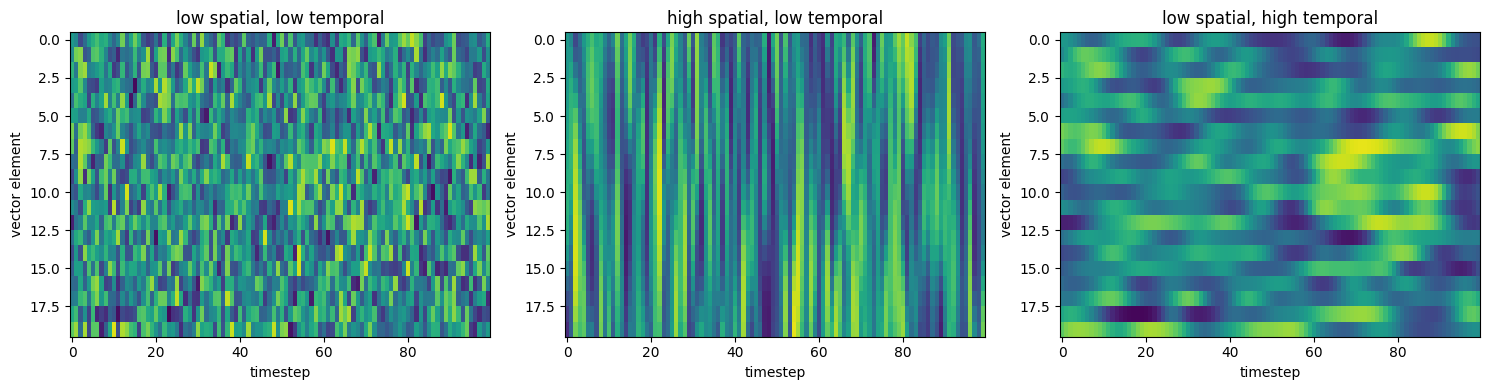

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    (0.5, 0.5, 'low spatial, low temporal'),
    (5.0, 0.5, 'high spatial, low temporal'),
    (0.5, 5.0, 'low spatial, high temporal'),
]
for ax, (spatial_t, temporal_t, label) in zip(axes, configs):
    task = GaussianProcessTask(vector_length=20, spatial_temperature=spatial_t, temporal_temperature=temporal_t)
    data = task.generate(num_steps=100, seed=0)
    im = ax.imshow(data.T, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(label)
    ax.set_xlabel('timestep')
    ax.set_ylabel('vector element')
plt.tight_layout()
plt.show()

## 4. Bifurcate

Ones encroach inward from both edges until they meet (all ones); then the zeros return either from the **middle** (ones retreat to the ends) or from the **ends** (ones shrink in the middle), each with probability 0.5, until all zeros -- and the cycle restarts. Which way the zeros return is the one unpredictable event.

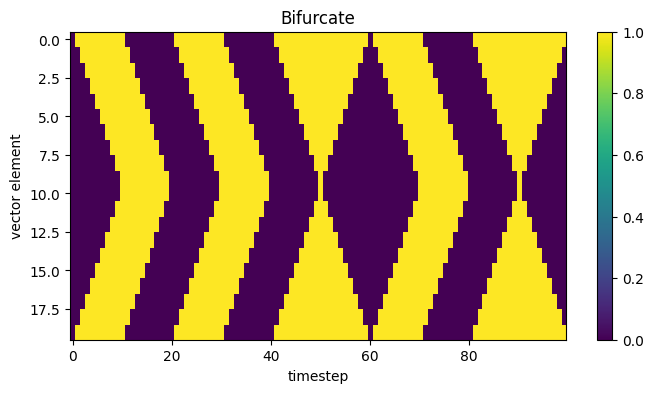

In [21]:
task = BifurcateTask(vector_length=20)
data = task.generate(num_steps=100, seed=1)
plot_timeseries(data, 'Bifurcate')